In [3]:
import pandas as pd
df1 = pd.read_csv ('subject-info.csv') 
df2 = pd.read_csv ('test_measure.csv')

In [4]:
#49. Identify the test name that had the shortest time duration. 

#Group by ID_test and calculate the duration of each test
test_duration = df2.groupby ('ID_test')['time'].max().reset_index()
#Rename the columns
test_duration.columns = ['ID_test', 'duration']
#Find the test with the shortest duration
shortest_test = test_duration.loc [test_duration['duration'].idxmin()]
print ("The test name with the shortest duration is:", shortest_test['ID_test'])

The test name with the shortest duration is: 564_1


In [5]:
#50. What is the percentage difference in mean Carbon dioxide production between male and female athletes?

#Merge the datasets on ID
merged_data = pd.merge (df1, df2, on='ID')
#Filter out the rows with missing VCO2 values
merged_data = merged_data.dropna (subset= ['VCO2'])
#Calculate mean VCO2 by sex
mean_male_vco2 = merged_data [merged_data ['Sex'] == 0] ['VCO2'].mean()
mean_female_vco2 = merged_data [merged_data ['Sex'] == 1] ['VCO2'].mean()
#Calculate percentage diff
percentage_diff = ((mean_male_vco2 - mean_female_vco2) / mean_female_vco2) * 100
print ("Percentage difference in mean Carbon dioxide production between male and female athletes:", percentage_diff)  

Percentage difference in mean Carbon dioxide production between male and female athletes: 41.430933327674005


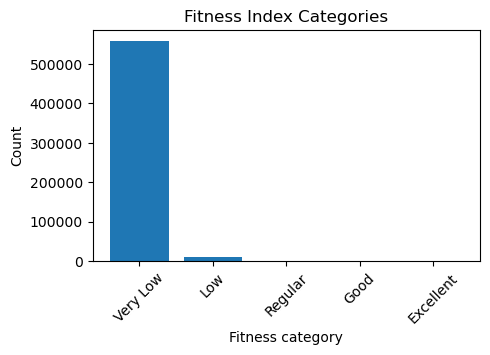

In [6]:
#51. Calculate the Fitness Index, generate a bar chart of Fitness Index categories, and export it as SVG file.

import matplotlib.pyplot as plt
import numpy as np
merged_data = pd.merge (df1, df2, on='ID_test')
#Calculate Fitness Index
merged_data['Fitness Index'] = (merged_data['Speed']*100) / (merged_data['Weight'] * (50/merged_data['Age']))
#Categorize Fitness Index
bins = [0,20,40,60,80,100]
labels = ['Very Low', 'Low', 'Regular', 'Good', 'Excellent']
merged_data['Fitness category'] = pd.cut (merged_data['Fitness Index'], bins= bins, labels= labels)
#Calculate count of each category 
category_counts = merged_data['Fitness category'].value_counts()
#Generate bar chart
plt.figure (figsize= (5,3))
plt.bar (category_counts.index, category_counts.values)
plt.xlabel ('Fitness category')
plt.ylabel ('Count')
plt.title ('Fitness Index Categories')
plt.xticks (rotation= 45)
#Export as SVG file
plt.savefig ('fitness_index_cateories', bbox_inches= 'tight')


In [7]:
#52. "arr=np.array([ [3, 5, 7, 9], [2, 0, 8, 10], [1, 4, 8, 12], [5, 9, 14, 15] ])
#Transpose this numpy matrix. and calculate sum of each row after transposing. Find the row with highest sum(after transposing)

arr=np.array([ [3, 5, 7, 9], [2, 0, 8, 10], [1, 4, 8, 12], [5, 9, 14, 15] ])
#Transpose the array
transposed_arr = arr.T
#Calculate the sum of each row after transposing
row_sums = np.sum (transposed_arr, axis=1)
#Find the row with highest sum
highest_sum_index = np.argmax (row_sums)
highest_sum_row = transposed_arr[highest_sum_index]
#Calculate maximum sum value
max_sum = np.max (row_sums)
print ("Original Array:\n", arr)
print ("\nTransposed Array:\n", transposed_arr)
print ("\nSum of each row after transposing:\n", row_sums)
print ("\nRow with highest sum:\n", highest_sum_row)
print ("\nmaximum sum value:", max_sum) 

Original Array:
 [[ 3  5  7  9]
 [ 2  0  8 10]
 [ 1  4  8 12]
 [ 5  9 14 15]]

Transposed Array:
 [[ 3  2  1  5]
 [ 5  0  4  9]
 [ 7  8  8 14]
 [ 9 10 12 15]]

Sum of each row after transposing:
 [11 18 37 46]

Row with highest sum:
 [ 9 10 12 15]

maximum sum value: 46


In [8]:
#53 Display participant details with highest average cardiorespiratory fitness in terms of VO2 max.

merged_data = pd.merge (df1, df2, on= ['ID', 'ID_test'])
merged_data['VO2_max'] =  merged_data['VO2'] / merged_data['Weight']
avg_VO2_max = merged_data.groupby('ID')['VO2_max'].mean().reset_index()
highest_avg_VO2_max_participant = avg_VO2_max.loc [avg_VO2_max['VO2_max'].idxmax()]
participant_details = df1.loc [df1['ID'] == highest_avg_VO2_max_participant['ID']]
print (participant_details)

      Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test
350  23.6    86.0   190.0      45.0         32.0    0  409   409_1


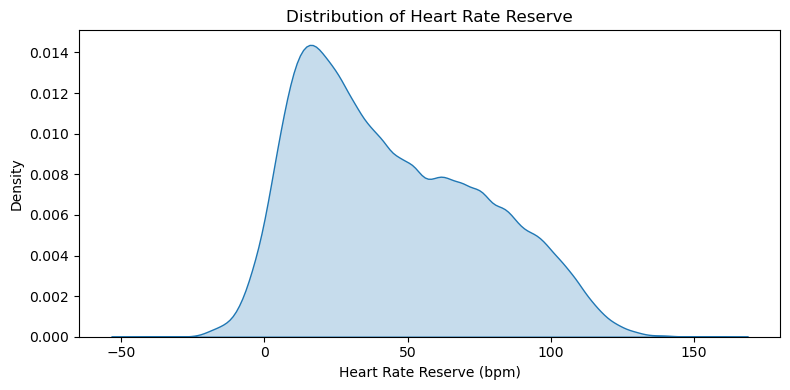

In [9]:
#54 calculate the heart rate reserve and show the distribution as density plot

import seaborn as sbn
merged_data = pd.merge (df1, df2, on= 'ID')
#Calculate the maximum heart rate for each participant
merged_data['Max_HR'] = 220 - merged_data['Age']
#Calculate the heart rate reserve for each participant
merged_data['HRR'] = merged_data['Max_HR'] - merged_data['HR']
#Genarate the density plot
plt.figure (figsize= (8,4))
sbn.kdeplot (merged_data['HRR'], fill= True)
plt.title ('Distribution of Heart Rate Reserve')
plt.xlabel ('Heart Rate Reserve (bpm)')
plt.ylabel ('Density')
plt.tight_layout()
plt.show()

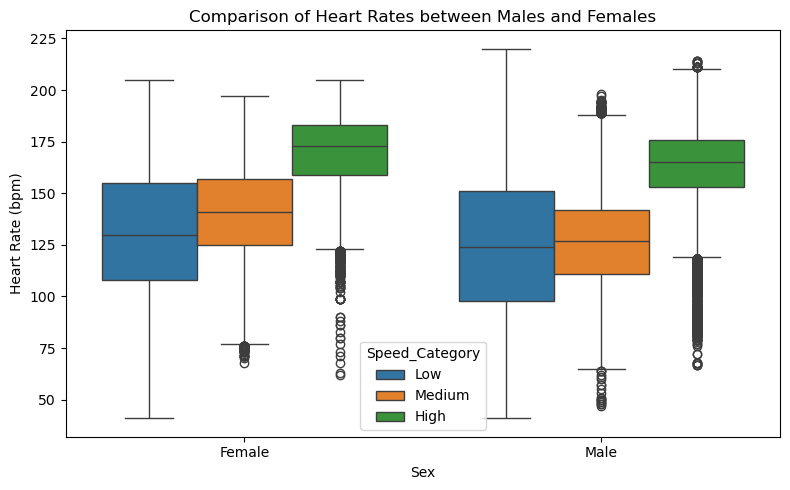

In [18]:
#55. Create a boxplot comparing heart rates between males and females, showing hue as speed category.

#Merge the dataframes
merged_data = pd.merge (df1, df2, on= 'ID')
#Create a new column for speed category 
merged_data['Speed_Category'] = pd.cut (merged_data['Speed'], bins= [0,5,10,15], labels= ['Low', 'Medium', 'High'])
#Map sex values to male and female
merged_data['Sex'] = merged_data['Sex'].map({0: 'Male', 1: 'Female'})
#Create a boxplot
plt.figure (figsize= (8,5))
sbn.boxplot (data= merged_data, x= 'Sex', y= 'HR', hue= 'Speed_Category')
plt.title ('Comparison of Heart Rates between Males and Females')
plt.xlabel ('Sex')
plt.ylabel ('Heart Rate (bpm)')
plt.tight_layout()
plt.show()

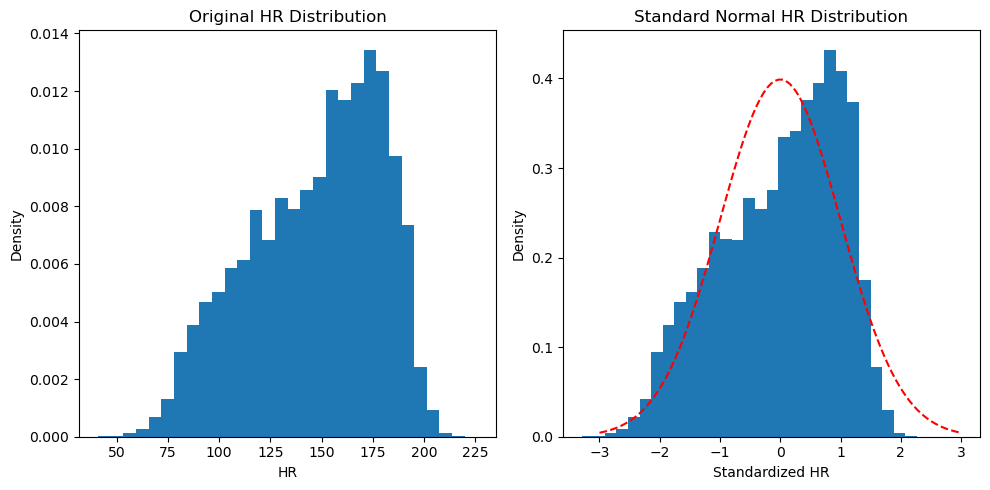

In [20]:
#56. Choose any feature that follows a Gaussian distribution, convert it into a standard normal distribution, and visualize the results?

import scipy.stats as stat
#Select the HR feature
hr = df2['HR']
#Calculate the mean and standard deviation
mean = hr.mean()
std_dev = hr.std()
#Convert the HR feature into standard normal distribution 
std_normal_hr = (hr-mean)/std_dev
#Plot the original HR feature
plt.figure (figsize= (10,5))
plt.subplot (1,2,1)
plt.hist (hr, bins= 30, density= True)
plt.title ('Original HR Distribution')
plt.xlabel ('HR')
plt.ylabel ('Density')
#Plot the standard normal HR feature
plt.subplot (1,2,2)
plt.hist (std_normal_hr, bins= 30, density= True)
plt.title ('Standard Normal HR Distribution')
plt.xlabel ('Standardized HR')
plt.ylabel ('Density')
x = np.linspace (-3,3,100)
plt.plot (x, stat.norm.pdf(x,0,1), 'r--')
plt.tight_layout()
plt.show()

In [26]:
#57. Identify the participant who has taken maximum number of Graded Exercise test and justify.

#Count the number of test per participant
GET_Count = df1['ID'].value_counts()
#Identify the participant with the maximum number of tests
max_GET_participant = GET_Count.idxmax()
max_GET_count = GET_Count.max()
print (f"Participant {max_GET_participant} has taken the maximum number of tests: {max_GET_count}")

#Justification:
#The participant with the maximum number of tests can be identified by counting the number of roes in the subject-info.csv file for each unique ID.
#The value_counts() method in pandas provide a convenient method to perform this count. The participant with the highest count is the one who has taken
#the maximum number of GETS

Participant 506 has taken the maximum number of tests: 5


In [ ]:
#58. For participant ID 725 show trend of  any three variables against time in a single canva ?